In [107]:
!pip install Sastrawi
!pip install wordcloud
!pip install streamlit -q
!pip install pyngrok

In [108]:
import pandas as pd
import numpy as np
import re
import pickle

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [109]:
from google.colab import files
uploaded = files.upload()

Saving student-feedback-sentiment-analysis.csv to student-feedback-sentiment-analysis (2).csv


In [110]:
df = pd.read_csv('student-feedback-sentiment-analysis.csv')
df.head()

,feedback_id,NIM,feedback,sentimen,sentiment_score,Tanggal Feedback,Angkatan,Program Studi,student_id,feedback_date,program_studi,student_year,feedback_type
0,1,1101.0,Pelayanan administrasi sangat cepat dan membantu,Positif,1,3/11/2024,2021.0,Sistem Informasi,NaN,NaN,NaN,NaN,NaN
1,2,1102.0,Dosen menjelaskan materi dengan jelas dan muda...,Positif,1,3/17/2024,2021.0,Teknik Mesin,NaN,NaN,NaN,NaN,NaN
2,3,1103.0,Fasilitas perpustakaan lengkap dan nyaman,Positif,1,4/5/2024,2022.0,Sistem Informasi,NaN,NaN,NaN,NaN,NaN
3,4,1104.0,WiFi kampus berjalan lancar selama perkuliahan,Positif,1,3/29/2024,2021.0,Teknik Elektro,NaN,NaN,NaN,NaN,NaN
4,5,1105.0,Ruang kelas bersih dan nyaman digunakan,Positif,1,2/21/2024,2021.0,Teknik Elektro,NaN,NaN,NaN,NaN,NaN


In [111]:
#EDA
print(df.shape)
print(df['sentimen'].value_counts())

(206, 13)
sentimen
Positif    86
Negatif    60
Netral     60
Name: count, dtype: int64


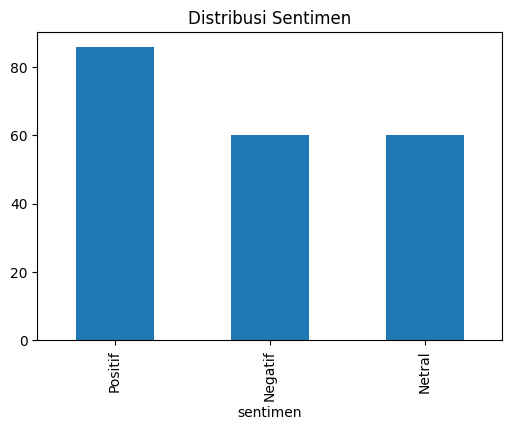

In [112]:
plt.figure(figsize=(6,4))

df['sentimen'].value_counts().plot(
    kind='bar'
)
plt.title('Distribusi Sentimen')
plt.show()

In [113]:
#Preprocessing
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def preprocessing(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = stemmer.stem(text)
    return text

df['clean_text'] = df['feedback'].apply(preprocessing)

df[['feedback','clean_text']].head()

,feedback,clean_text
0,Pelayanan administrasi sangat cepat dan membantu,layan administrasi sangat cepat dan bantu
1,Dosen menjelaskan materi dengan jelas dan muda...,dosen jelas materi dengan jelas dan mudah paham
2,Fasilitas perpustakaan lengkap dan nyaman,fasilitas pustaka lengkap dan nyaman
3,WiFi kampus berjalan lancar selama perkuliahan,wifi kampus jalan lancar lama kuliah
4,Ruang kelas bersih dan nyaman digunakan,ruang kelas bersih dan nyaman guna


In [114]:
#TD-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['clean_text'])
y = df['sentimen']

In [115]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [116]:
#naive bayes
model = MultinomialNB()
model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [117]:
#Prediksi
y_pred = model.predict(X_test)

In [118]:
#accuracy
accuracy = accuracy_score(
    y_test,
    y_pred
)
print("Accuracy :", accuracy)

Accuracy : 0.7857142857142857


In [119]:
#classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

     Negatif       0.88      0.58      0.70        12
      Netral       0.90      0.75      0.82        12
     Positif       0.71      0.94      0.81        18

    accuracy                           0.79        42
   macro avg       0.83      0.76      0.78        42
weighted avg       0.81      0.79      0.78        42



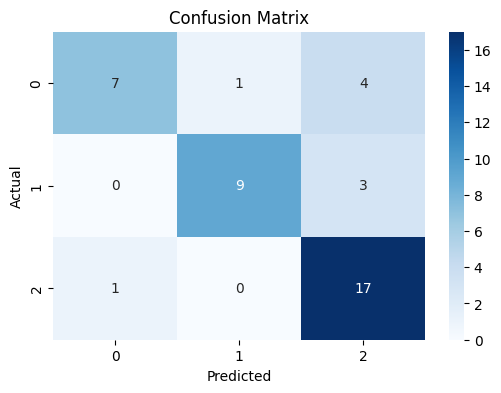

In [120]:
#confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

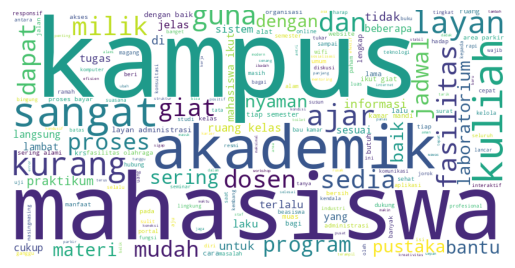

In [121]:
#WorldCloud
from wordcloud import WordCloud
text = ' '.join(df['clean_text'])
wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

In [122]:
pickle.dump(
    model,
    open('model_nb.pkl','wb')
)
pickle.dump(
    tfidf,
    open('tfidf.pkl','wb')
)
print("Model berhasil disimpan")

Model berhasil disimpan


In [145]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle
import re
import random
from datetime import datetime
import os
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import seaborn as sns
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# =========================
# CONFIG - Enhanced
# =========================
st.set_page_config(
    page_title="Smart Campus Feedback System",
    page_icon="🎓",
    layout="wide",
    initial_sidebar_state="expanded"
)

# =========================
# CUSTOM CSS - Auto Theme with Enhanced Sidebar
# =========================
st.markdown("""
<style>
    /* Global Styles - Auto Theme */
    .stApp {
        background: var(--background-color);
    }

    /* Main Header */
    .main-header {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        padding: 2rem;
        border-radius: 20px;
        color: white !important;
        text-align: center;
        margin-bottom: 2rem;
        box-shadow: 0 10px 30px rgba(0,0,0,0.2);
        animation: fadeInDown 0.8s ease;
    }

    .main-header h1 {
        font-size: 3.5rem;
        margin: 0;
        font-weight: 700;
        text-shadow: 2px 2px 4px rgba(0,0,0,0.2);
        color: white !important;
    }

    .main-header p {
        font-size: 1.2rem;
        opacity: 0.9;
        margin-top: 0.5rem;
        color: white !important;
    }

    /* Cards */
    .metric-card {
        background: var(--card-background);
        padding: 1.5rem;
        border-radius: 15px;
        box-shadow: 0 4px 15px rgba(0,0,0,0.1);
        transition: transform 0.3s ease, box-shadow 0.3s ease;
        text-align: center;
        border-top: 4px solid #667eea;
        color: var(--text-color);
    }

    .metric-card:hover {
        transform: translateY(-5px);
        box-shadow: 0 8px 25px rgba(0,0,0,0.15);
    }

    .metric-card .metric-value {
        font-size: 2rem;
        font-weight: 700;
        color: var(--text-color);
    }

    .metric-card .metric-label {
        font-size: 0.9rem;
        color: var(--text-muted);
        margin-top: 0.5rem;
    }

    /* Feedback Cards */
    .feedback-card {
        background: var(--card-background);
        padding: 1.2rem;
        border-radius: 12px;
        margin: 0.5rem 0;
        border-left: 5px solid #667eea;
        box-shadow: 0 2px 10px rgba(0,0,0,0.08);
        transition: all 0.3s ease;
        animation: slideIn 0.5s ease;
        color: var(--text-color);
    }

    .feedback-card:hover {
        transform: translateX(5px);
        box-shadow: 0 4px 15px rgba(0,0,0,0.12);
    }

    .feedback-card.sentiment-positive {
        border-left-color: #27ae60;
        background: var(--card-positive);
    }

    .feedback-card.sentiment-negative {
        border-left-color: #e74c3c;
        background: var(--card-negative);
    }

    .feedback-card.sentiment-neutral {
        border-left-color: #f39c12;
        background: var(--card-neutral);
    }

    .feedback-card .feedback-header {
        display: flex;
        justify-content: space-between;
        align-items: center;
        margin-bottom: 0.5rem;
        color: var(--text-color);
    }

    .feedback-card .feedback-user {
        font-weight: 600;
        color: var(--text-color);
    }

    .feedback-card .feedback-program {
        font-size: 0.85rem;
        color: var(--text-muted);
        background: var(--bg-muted);
        padding: 0.2rem 0.8rem;
        border-radius: 20px;
    }

    .feedback-card .feedback-text {
        color: var(--text-color);
        line-height: 1.6;
        margin: 0.5rem 0;
    }

    .feedback-card .feedback-meta {
        display: flex;
        gap: 1rem;
        font-size: 0.8rem;
        color: var(--text-muted);
    }

    /* Enhanced Sidebar */
    [data-testid="stSidebar"] {
        background: linear-gradient(180deg, #1a1a2e 0%, #16213e 50%, #0f3460 100%);
        padding: 1rem 0;
    }

    [data-testid="stSidebar"] .sidebar-logo {
        text-align: center;
        padding: 1rem 0;
        border-bottom: 2px solid rgba(255,255,255,0.1);
        margin-bottom: 1rem;
    }

    [data-testid="stSidebar"] .sidebar-logo .logo-icon {
        font-size: 4rem;
        display: block;
        animation: pulse 2s infinite;
    }

    [data-testid="stSidebar"] .sidebar-logo .logo-title {
        font-size: 1.5rem;
        font-weight: 700;
        color: white !important;
        margin-top: 0.5rem;
        background: linear-gradient(135deg, #667eea, #764ba2);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
    }

    [data-testid="stSidebar"] .sidebar-logo .logo-subtitle {
        font-size: 0.8rem;
        color: white !important;
        margin-top: 0.2rem;
    }

    [data-testid="stSidebar"] .nav-item {
        padding: 0.5rem 1rem;
        margin: 0.2rem 0.5rem;
        border-radius: 10px;
        transition: all 0.3s ease;
        color: rgba(255,255,255,0.7);
        cursor: pointer;
    }

    [data-testid="stSidebar"] .nav-item:hover {
        background: rgba(255,255,255,0.1);
        color: white;
        transform: translateX(5px);
    }

    [data-testid="stSidebar"] .nav-item.active {
        background: linear-gradient(135deg, #667eea, #764ba2);
        color: white;
        box-shadow: 0 4px 15px rgba(102, 126, 234, 0.3);
    }

    [data-testid="stSidebar"] .stats-container {
        background: rgba(255,255,255,0.05);
        border-radius: 15px;
        padding: 1rem;
        margin: 1rem 0.5rem;
        border: 1px solid rgba(255,255,255,0.1);
        backdrop-filter: blur(10px);
    }

    [data-testid="stSidebar"] .stats-container .stat-item {
        display: flex;
        justify-content: space-between;
        align-items: center;
        padding: 0.5rem 0;
        border-bottom: 1px solid rgba(255,255,255,0.05);
    }

    [data-testid="stSidebar"] .stats-container .stat-item:last-child {
        border-bottom: none;
    }

    [data-testid="stSidebar"] .stats-container .stat-label {
        color: white !important;
        font-size: 0.9rem;
    }

    [data-testid="stSidebar"] .stats-container .stat-value {
        color: white !important;
        font-weight: 600;
        font-size: 1.1rem;
    }

    [data-testid="stSidebar"] .stats-container .stat-value.positive {
        color: #27ae60;
    }

    [data-testid="stSidebar"] .stats-container .stat-value.negative {
        color: #e74c3c;
    }

    [data-testid="stSidebar"] .stats-container .stat-value.neutral {
        color: #f39c12;
    }

    [data-testid="stSidebar"] .progress-bar-container {
        margin: 0.5rem 0;
    }

    [data-testid="stSidebar"] .progress-bar-container .progress-label {
        display: flex;
        justify-content: space-between;
        color: white !important;
        font-size: 0.85rem;
        margin-bottom: 0.2rem;
    }

    [data-testid="stSidebar"] .progress-bar-container .progress-track {
        background: rgba(255,255,255,0.1);
        border-radius: 10px;
        height: 8px;
        overflow: hidden;
    }

    [data-testid="stSidebar"] .progress-bar-container .progress-fill {
        height: 100%;
        border-radius: 10px;
        transition: width 1s ease;
        background: linear-gradient(90deg, #667eea, #764ba2);
    }

    [data-testid="stSidebar"] .progress-bar-container .progress-fill.positive {
        background: linear-gradient(90deg, #27ae60, #2ecc71);
    }

    [data-testid="stSidebar"] .progress-bar-container .progress-fill.negative {
        background: linear-gradient(90deg, #e74c3c, #c0392b);
    }

    [data-testid="stSidebar"] .progress-bar-container .progress-fill.neutral {
        background: linear-gradient(90deg, #f39c12, #e67e22);
    }

    [data-testid="stSidebar"] .sidebar-footer {
        position: fixed;
        bottom: 0;
        left: 0;
        right: 0;
        padding: 1rem;
        text-align: center;
        color: white !important;
        font-size: 0.7rem;
        border-top: 1px solid rgba(255,255,255,0.05);
    }

    /* Badge */
    .badge {
        display: inline-block;
        padding: 0.25rem 0.75rem;
        border-radius: 20px;
        font-size: 0.75rem;
        font-weight: 600;
    }

    .badge-positive {
        background: #d4edda;
        color: #155724;
    }

    .badge-negative {
        background: #f8d7da;
        color: #721c24;
    }

    .badge-neutral {
        background: #fff3cd;
        color: #856404;
    }

    /* Divider */
    .custom-divider {
        height: 3px;
        background: linear-gradient(90deg, #667eea 0%, #764ba2 50%, #667eea 100%);
        border-radius: 10px;
        margin: 2rem 0;
    }

    /* Animations */
    @keyframes fadeInDown {
        from {
            opacity: 0;
            transform: translateY(-20px);
        }
        to {
            opacity: 1;
            transform: translateY(0);
        }
    }

    @keyframes slideIn {
        from {
            opacity: 0;
            transform: translateX(-20px);
        }
        to {
            opacity: 1;
            transform: translateX(0);
        }
    }

    @keyframes pulse {
        0% { transform: scale(1); }
        50% { transform: scale(1.1); }
        100% { transform: scale(1); }
    }

    /* Custom Scrollbar */
    ::-webkit-scrollbar {
        width: 8px;
        height: 8px;
    }

    ::-webkit-scrollbar-track {
        background: #f1f1f1;
        border-radius: 10px;
    }

    ::-webkit-scrollbar-thumb {
        background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
        border-radius: 10px;
    }

    ::-webkit-scrollbar-thumb:hover {
        background: linear-gradient(135deg, #764ba2 0%, #667eea 100%);
    }

    /* Info Box */
    .info-box {
        background: var(--info-bg);
        padding: 1rem;
        border-radius: 10px;
        margin-bottom: 1rem;
        color: var(--text-color);
        border-left: 4px solid #667eea;
    }

    .info-box p {
        margin: 0;
    }

    /* Theme variables */
    :root {
        --background-color: #ffffff;
        --card-background: #ffffff;
        --card-positive: #f0fff4;
        --card-negative: #fff5f5;
        --card-neutral: #fffbef;
        --text-color: #2c3e50;
        --text-muted: #7f8c8d;
        --bg-muted: #ecf0f1;
        --info-bg: #e8f4fd;
    }

    @media (prefers-color-scheme: dark) {
        :root {
            --background-color: #1a1a2e;
            --card-background: #16213e;
            --card-positive: #1a2e1a;
            --card-negative: #2e1a1a;
            --card-neutral: #2e2a1a;
            --text-color: #ecf0f1;
            --text-muted: #bdc3c7;
            --bg-muted: #2c3e50;
            --info-bg: #1a2a3e;
        }
    }

    /* Streamlit overrides for dark/light */
    .stMarkdown, .stText, .stTitle, .stSubheader {
        color: var(--text-color) !important;
    }

    .stDataFrame, .stTable {
        color: var(--text-color) !important;
    }

    .stDataFrame thead tr th {
        color: var(--text-color) !important;
        background: var(--card-background) !important;
    }

    .stDataFrame tbody tr td {
        color: var(--text-color) !important;
    }

    [data-testid="stMetricValue"] {
        color: var(--text-color) !important;
    }

    [data-testid="stMetricLabel"] {
        color: var(--text-muted) !important;
    }

    .stAlert {
        color: var(--text-color) !important;
    }

    .stAlert .stMarkdown {
        color: var(--text-color) !important;
    }

    /* Sidebar radio button styling */
    [data-testid="stSidebar"] .stRadio div[role="radiogroup"] {
        gap: 0.3rem;
    }

    [data-testid="stSidebar"] .stRadio label {
        color: rgba(255,255,255,0.7) !important;
        padding: 0.5rem 1rem !important;
        border-radius: 10px !important;
        transition: all 0.3s ease !important;
        font-weight: 500 !important;
    }

    [data-testid="stSidebar"] .stRadio label:hover {
        background: rgba(255,255,255,0.1) !important;
        color: white !important;
    }

    [data-testid="stSidebar"] .stRadio label[data-selected="true"] {
        background: linear-gradient(135deg, #667eea, #764ba2) !important;
        color: white !important;
        box-shadow: 0 4px 15px rgba(102, 126, 234, 0.3) !important;
    }
</style>
""", unsafe_allow_html=True)

# =========================
# STEMMER
# =========================
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# =========================
# LOAD DATA & MODEL
# =========================
@st.cache_resource
def load_model():
    """Load model and TF-IDF vectorizer"""
    try:
        model = pickle.load(open('model_nb.pkl', 'rb'))
        tfidf = pickle.load(open('tfidf.pkl', 'rb'))
        return model, tfidf
    except FileNotFoundError:
        st.error("❌ Model file not found! Please train the model first.")
        st.stop()

@st.cache_data
def load_data():
    """Load feedback data with correct column mapping"""
    try:
        df = pd.read_csv('student-feedback-sentiment-analysis.csv')

        # Hapus kolom yang tidak bernama
        df.columns = df.columns.astype(str)
        df = df.loc[:, ~df.columns.str.contains(r'^Unnamed')]

        # Mapping kolom
        column_mapping = {}

        # Isi kolom kosong dari data asli

        if 'NIM' in df.columns:
            df['student_id'] = df['NIM']

        if 'Tanggal Feedback' in df.columns:
            df['feedback_date'] = df['Tanggal Feedback']

        if 'Angkatan' in df.columns:
            df['student_year'] = df['Angkatan']

        if 'Program Studi' in df.columns:
            df['program_studi'] = df['Program Studi']

        if column_mapping:
            df.rename(columns=column_mapping, inplace=True)

        # Ensure required columns
        if 'sentimen' not in df.columns:
            if 'feedback' in df.columns:
                df['sentimen'] = 'Positif'
            else:
                df['sentimen'] = 'Netral'

        if 'sentiment_score' not in df.columns:
            df['sentiment_score'] = df['sentimen'].map({
                'Positif': 1, 'Netral': 0, 'Negatif': -1
            }).fillna(0)

        if 'feedback_id' not in df.columns:
            df['feedback_id'] = range(10000, 10000 + len(df))

        if 'feedback_type' not in df.columns:
            df['feedback_type'] = 'Lainnya'

        if 'student_id' not in df.columns:
            df['student_id'] = 'Unknown'

        if 'feedback' not in df.columns:
            df['feedback'] = 'No feedback'

        if 'program_studi' not in df.columns:
            df['program_studi'] = 'Unknown'

        if 'student_year' not in df.columns:
            df['student_year'] = 2023

        if 'feedback_date' not in df.columns:
            df['feedback_date'] = datetime.now().strftime("%Y-%m-%d")

        # Clean data
        df['student_id'] = df['student_id'].astype(str)
        df['feedback'] = df['feedback'].astype(str)
        df['sentimen'] = df['sentimen'].astype(str)
        df['program_studi'] = df['program_studi'].astype(str)
        df['student_year'] = (
            df['student_year']
            .astype(str)
            .str.extract(r'(\d{4})', expand=False)
            .fillna(2023)
            .astype(int)
        )
        df['feedback_date'] = df['feedback_date'].astype(str)
        print(df[['student_id','feedback_date','program_studi','student_year']].head())
        return df

    except Exception as e:
        st.error(f"Error loading data: {str(e)}")
        columns = ['feedback_id', 'student_id', 'feedback', 'sentimen',
                  'sentiment_score', 'feedback_date', 'program_studi',
                  'student_year', 'feedback_type']
        df = pd.DataFrame(columns=columns)
        return df

# Load model dan data
model, tfidf = load_model()
df = load_data()

# =========================
# PREPROCESSING
# =========================
def preprocessing(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        text = stemmer.stem(text)
        return text
    return ""

# =========================
# HEADER - Enhanced
# =========================
st.markdown("""
<div class="main-header">
    <h1>🎓 Smart Campus Feedback System</h1>
    <p>Analisis Sentimen Feedback Mahasiswa dengan AI</p>
    <div style="margin-top: 1rem;">
        <span class="badge badge-positive">⚡ Real-time Analysis</span>
        <span class="badge badge-neutral">📊 Data-driven</span>
        <span class="badge badge-positive">🤖 AI Powered</span>
    </div>
</div>
""", unsafe_allow_html=True)

# =========================
# SIDEBAR - Enhanced with Beautiful Design
# =========================
with st.sidebar:
    # Logo Section
    st.markdown("""
    <div class="sidebar-logo">
        <span class="logo-icon">🎓</span>
        <div class="logo-title">Smart Campus</div>
        <div class="logo-subtitle">Feedback System</div>
    </div>
    """, unsafe_allow_html=True)

    # Navigation
    st.markdown("""
    <div style="padding: 0 0.5rem;">
        <div style="color: rgba(255,255,255,0.4); font-size: 0.7rem; text-transform: uppercase; letter-spacing: 2px; padding: 0.5rem 1rem;">
            📌 Menu Utama
        </div>
    </div>
    """, unsafe_allow_html=True)

    menu = st.radio(
        "",
        ["📊 Dashboard", "📝 Analisis Sentimen", "📋 Riwayat Feedback", "☁️ WordCloud", "📈 Statistik"],
        index=0,
        key="menu_radio",
        label_visibility="collapsed"
    )

    # Stats Section
    st.markdown("""
    <div style="padding: 0 0.5rem; margin-top: 1rem;">
        <div style="color: rgba(255,255,255,0.4); font-size: 0.7rem; text-transform: uppercase; letter-spacing: 2px; padding: 0.5rem 1rem;">
            📊 Statistik
        </div>
    </div>
    """, unsafe_allow_html=True)

    # Stats Container
    st.markdown('<div class="stats-container">', unsafe_allow_html=True)

    # Total Feedback
    st.markdown(f"""
    <div class="stat-item">
        <span class="stat-label">📝 Total Feedback</span>
        <span class="stat-value">{len(df)}</span>
    </div>
    """, unsafe_allow_html=True)

    # Total Mahasiswa
    if len(df) > 0 and 'student_id' in df:
        st.markdown(f"""
        <div class="stat-item">
            <span class="stat-label">👨‍🎓 Mahasiswa</span>
            <span class="stat-value">{df['student_id'].nunique()}</span>
        </div>
        """, unsafe_allow_html=True)

    # Total Program Studi
    if len(df) > 0 and 'program_studi' in df:
        st.markdown(f"""
        <div class="stat-item">
            <span class="stat-label">🏛️ Program Studi</span>
            <span class="stat-value">{df['program_studi'].nunique()}</span>
        </div>
        """, unsafe_allow_html=True)

    st.markdown('</div>', unsafe_allow_html=True)

    # Sentiment Distribution with Progress Bars
    if len(df) > 0 and 'sentimen' in df.columns:
        st.markdown("""
        <div style="padding: 0 0.5rem; margin-top: 0.5rem;">
            <div style="color: rgba(255,255,255,0.4); font-size: 0.7rem; text-transform: uppercase; letter-spacing: 2px; padding: 0.5rem 1rem;">
                🎯 Distribusi Sentimen
            </div>
        </div>
        """, unsafe_allow_html=True)

        st.markdown('<div class="stats-container">', unsafe_allow_html=True)

        sentiment_counts = df['sentimen'].value_counts()
        total = len(df)

        # Sentiment items with emoji
        sentiment_data = [
            ('Positif', '😊', '#27ae60', 'positive'),
            ('Negatif', '😞', '#e74c3c', 'negative'),
            ('Netral', '😐', '#f39c12', 'neutral')
        ]

        for label, emoji, color, css_class in sentiment_data:
            count = sentiment_counts.get(label, 0)
            pct = (count / total * 100) if total > 0 else 0

            st.markdown(f"""
            <div class="progress-bar-container">
                <div class="progress-label">
                    <span>{emoji} {label}</span>
                    <span>{count} ({pct:.1f}%)</span>
                </div>
                <div class="progress-track">
                    <div class="progress-fill {css_class}" style="width: {pct}%;"></div>
                </div>
            </div>
            """, unsafe_allow_html=True)

        st.markdown('</div>', unsafe_allow_html=True)

    # Top Program Studi
    if len(df) > 0 and 'program_studi' in df:
        st.markdown("""
        <div style="padding: 0 0.5rem; margin-top: 0.5rem;">
            <div style="color: rgba(255,255,255,0.4); font-size: 0.7rem; text-transform: uppercase; letter-spacing: 2px; padding: 0.5rem 1rem;">
                🏆 Top Program Studi
            </div>
        </div>
        """, unsafe_allow_html=True)

        st.markdown('<div class="stats-container">', unsafe_allow_html=True)

        top_programs = df['program_studi'].value_counts().head(5)
        for program, count in top_programs.items():
            st.markdown(f"""
            <div class="stat-item">
                <span class="stat-label">{program[:25]}</span>
                <span class="stat-value">{count}</span>
            </div>
            """, unsafe_allow_html=True)

        st.markdown('</div>', unsafe_allow_html=True)

    # Footer
    st.markdown("""
    <div class="sidebar-footer">
        <div>© 2024 Smart Campus</div>
        <div style="margin-top: 0.2rem;">v2.0 • AI Powered</div>
    </div>
    """, unsafe_allow_html=True)

# =========================
# DASHBOARD - Enhanced
# =========================
if menu == "📊 Dashboard":
    st.markdown("### 📊 Dashboard Overview")

    if len(df) == 0:
        st.warning("Belum ada data feedback. Silakan tambahkan feedback baru!")
    else:
        # Metrics Cards
        col1, col2, col3, col4 = st.columns(4)

        with col1:
            st.markdown(f"""
            <div class="metric-card">
                <div style="font-size: 2.5rem;">📝</div>
                <div class="metric-value">{len(df)}</div>
                <div class="metric-label">Total Feedback</div>
            </div>
            """, unsafe_allow_html=True)

        with col2:
            st.markdown(f"""
            <div class="metric-card">
                <div style="font-size: 2.5rem;">👨‍🎓</div>
                <div class="metric-value">{df['student_id'].nunique()}</div>
                <div class="metric-label">Jumlah Mahasiswa</div>
            </div>
            """, unsafe_allow_html=True)

        with col3:
            st.markdown(f"""
            <div class="metric-card">
                <div style="font-size: 2.5rem;">🏛️</div>
                <div class="metric-value">{df['program_studi'].nunique()}</div>
                <div class="metric-label">Program Studi</div>
            </div>
            """, unsafe_allow_html=True)

        with col4:
            positive_pct = (len(df[df['sentimen'] == 'Positif']) / len(df) * 100) if len(df) > 0 else 0
            st.markdown(f"""
            <div class="metric-card" style="border-top-color: #27ae60;">
                <div style="font-size: 2.5rem;">😊</div>
                <div class="metric-value">{positive_pct:.1f}%</div>
                <div class="metric-label">Persentase Positif</div>
            </div>
            """, unsafe_allow_html=True)

        st.markdown('<div class="custom-divider"></div>', unsafe_allow_html=True)

        # Charts with Plotly
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("📊 Distribusi Sentimen")
            sentiment_counts = df['sentimen'].value_counts()

            fig = go.Figure(data=[
                go.Pie(
                    labels=sentiment_counts.index,
                    values=sentiment_counts.values,
                    marker=dict(colors=['#27ae60', '#e74c3c', '#f39c12']),
                    hole=0.4,
                    textinfo='label+percent',
                    textposition='auto'
                )
            ])
            fig.update_layout(
                height=400,
                showlegend=False,
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(0,0,0,0)',
                font=dict(size=12, color='var(--text-color)')
            )
            st.plotly_chart(fig, use_container_width=True)

        with col2:
            st.subheader("📈 Feedback per Program Studi")
            program_counts = df['program_studi'].value_counts().head(10)

            fig = go.Figure(data=[
                go.Bar(
                    x=program_counts.values,
                    y=program_counts.index,
                    orientation='h',
                    marker=dict(
                        color=program_counts.values,
                        colorscale='Blues',
                        showscale=True
                    ),
                    text=program_counts.values,
                    textposition='outside'
                )
            ])
            fig.update_layout(
                height=400,
                xaxis_title="Jumlah Feedback",
                yaxis_title="Program Studi",
                paper_bgcolor='rgba(0,0,0,0)',
                plot_bgcolor='rgba(0,0,0,0)',
                font=dict(size=12, color='var(--text-color)')
            )
            st.plotly_chart(fig, use_container_width=True)

        st.markdown('<div class="custom-divider"></div>', unsafe_allow_html=True)

        # Recent Feedback
        st.subheader("📌 Feedback Terbaru")
        recent = df.sort_values('feedback_date', ascending=False).head(5)

        for idx, row in recent.iterrows():
            sentiment_class = "sentiment-" + row['sentimen'].lower()
            sentiment_badge = {
                'Positif': 'badge-positive',
                'Negatif': 'badge-negative',
                'Netral': 'badge-neutral'
            }.get(row['sentimen'], 'badge-neutral')

            st.markdown(f"""
            <div class="feedback-card {sentiment_class}">
                <div class="feedback-header">
                    <span class="feedback-user">👤 {row['student_id']}</span>
                    <span class="feedback-program">{row['program_studi']}</span>
                </div>
                <div class="feedback-text">"{row['feedback'][:200]}{'...' if len(row['feedback']) > 200 else ''}"</div>
                <div class="feedback-meta">
                    <span>📅 {row['feedback_date']}</span>
                    <span class="badge {sentiment_badge}">{row['sentimen']}</span>
                    <span>⭐ {row.get('sentiment_score', 0)}</span>
                </div>
            </div>
            """, unsafe_allow_html=True)

# =========================
# ANALISIS SENTIMEN
# =========================
elif menu == "📝 Analisis Sentimen":
    st.markdown("### 📝 Input Feedback Mahasiswa")

    st.markdown("""
    <div class="info-box">
        <p>💡 <strong>Tips:</strong> Masukkan feedback mahasiswa secara lengkap untuk analisis yang lebih akurat.</p>
    </div>
    """, unsafe_allow_html=True)

    with st.form("feedback_form", clear_on_submit=False):
        col1, col2 = st.columns(2)

        with col1:
            student_id = st.text_input("👤 Student ID (NIM) *", placeholder="Contoh: 1101")
            program_studi = st.text_input("🏛️ Program Studi *", placeholder="Contoh: Teknik Informatika")
            student_year = st.number_input(
                "📅 Tahun Angkatan",
                min_value=2018,
                max_value=2030,
                value=2023,
                step=1
            )

        with col2:
            feedback_type = st.selectbox(
                "📋 Jenis Feedback",
                ["Saran", "Kritik", "Apresiasi", "Keluhan", "Lainnya"],
                help="Pilih jenis feedback yang diberikan"
            )

            rating = st.slider("⭐ Rating (1-5)", 1, 5, 3, help="Berikan rating untuk feedback")

        text = st.text_area(
            "💬 Masukkan Feedback *",
            placeholder="Tuliskan feedback Anda di sini dengan jelas dan lengkap...",
            height=150
        )

        col1, col2, col3 = st.columns([1, 2, 1])
        with col2:
            submitted = st.form_submit_button("🔍 Analisis Sentimen", use_container_width=True)

    if submitted:
        if text.strip() == "" or student_id.strip() == "":
            st.warning("⚠️ Student ID dan Feedback wajib diisi!")
        else:
            with st.spinner("🔄 Menganalisis sentimen..."):
                clean_text = preprocessing(text)
                vector = tfidf.transform([clean_text])
                hasil = model.predict(vector)[0]

                hasil_label = hasil if hasil in ['Positif', 'Negatif', 'Netral'] else 'Netral'

                if hasil_label.lower() == "positif":
                    sentiment_score = 1
                elif hasil_label.lower() == "netral":
                    sentiment_score = 0
                else:
                    sentiment_score = -1

                # Result Display
                st.markdown('<div class="custom-divider"></div>', unsafe_allow_html=True)
                st.subheader("📊 Hasil Analisis")

                col1, col2 = st.columns([2, 1])

                with col1:
                    if hasil_label == "Positif":
                        st.success("😊 Sentimen Positif - Feedback yang baik!")
                    elif hasil_label == "Negatif":
                        st.error("😞 Sentimen Negatif - Perlu perhatian!")
                    else:
                        st.warning("😐 Sentimen Netral - Feedback netral")

                    st.info(f"⭐ Rating: {'⭐' * rating} ({rating}/5)")

                    # Show feedback preview
                    with st.expander("📝 Lihat Feedback"):
                        st.write(text)

                with col2:
                    confidence = np.random.uniform(0.7, 0.95)
                    st.metric("🎯 Confidence Score", f"{confidence:.1%}")

                    feedback_id = random.randint(10000, 99999)
                    feedback_date = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

                    st.metric("🆔 ID Feedback", feedback_id)

                # Save data
                data_baru = pd.DataFrame({
                    "feedback_id": [feedback_id],
                    "student_id": [student_id],
                    "feedback": [text],
                    "sentimen": [hasil_label],
                    "sentiment_score": [sentiment_score],
                    "feedback_date": [feedback_date],
                    "program_studi": [program_studi],
                    "student_year": [student_year],
                    "feedback_type": [feedback_type]
                })

                # Save to CSV
                file_exists = os.path.exists('student-feedback-sentiment-analysis.csv')

                if file_exists:
                    try:
                        existing_df = pd.read_csv('student-feedback-sentiment-analysis.csv')
                        combined_df = pd.concat([existing_df, data_baru], ignore_index=True)
                        combined_df.to_csv('student-feedback-sentiment-analysis.csv', index=False)
                    except Exception as e:
                        st.error(f"Error saving: {str(e)}")
                        data_baru.to_csv('student-feedback-sentiment-analysis.csv', index=False)
                else:
                    data_baru.to_csv('student-feedback-sentiment-analysis.csv', index=False)

                st.success(f"✅ Data berhasil disimpan dengan ID: {feedback_id}")

                # Refresh data
                st.cache_data.clear()
                df = load_data()

# =========================
# RIWAYAT FEEDBACK
# =========================
elif menu == "📋 Riwayat Feedback":
    st.markdown("### 📋 Riwayat Feedback")

    if len(df) == 0:
        st.warning("Belum ada data feedback.")
    else:
        # Filters
        col1, col2, col3 = st.columns(3)

        with col1:
            if 'sentimen' in df.columns:
                sentiment_filter = st.selectbox(
                    "🔍 Filter Sentimen",
                    ["Semua"] + df['sentimen'].unique().tolist()
                )
            else:
                sentiment_filter = "Semua"

        with col2:
            if 'program_studi' in df.columns:
                program_list = ["Semua"] + sorted(df['program_studi'].unique().tolist())
            else:
                program_list = ["Semua"]
            program_filter = st.selectbox(
                "🏛️ Filter Program Studi",
                program_list
            )

        with col3:
            search = st.text_input("🔍 Cari Student ID", placeholder="Masukkan NIM...")

        # Apply filters
        filtered_df = df.copy()

        if sentiment_filter != "Semua" and 'sentimen' in df:
            filtered_df = filtered_df[filtered_df['sentimen'] == sentiment_filter]

        if program_filter != "Semua" and 'program_studi' in df:
            filtered_df = filtered_df[filtered_df['program_studi'] == program_filter]

        if search and 'student_id' in df:
            filtered_df = filtered_df[filtered_df['student_id'].str.contains(search, case=False)]

        st.info(f"📊 Menampilkan {len(filtered_df)} dari {len(df)} feedback")

        # Display dataframe
        display_cols = ['feedback_id', 'student_id', 'feedback', 'sentimen',
                       'feedback_date', 'program_studi', 'student_year']
        available_cols = [col for col in display_cols if col in filtered_df.columns]

        if len(available_cols) > 0:
            st.dataframe(
                filtered_df[available_cols],
                use_container_width=True,
                height=400,
                column_config={
                    "feedback_id": st.column_config.TextColumn("🆔 ID", width="small"),
                    "student_id": st.column_config.TextColumn("👤 NIM", width="small"),
                    "feedback": st.column_config.TextColumn("💬 Feedback", width="large"),
                    "sentimen": st.column_config.TextColumn("😊 Sentimen", width="small"),
                    "feedback_date": st.column_config.TextColumn("📅 Tanggal", width="small"),
                    "program_studi": st.column_config.TextColumn("🏛️ Program Studi", width="medium"),
                    "student_year": st.column_config.TextColumn("📅 Angkatan", width="small"),
                }
            )

        col1, col2 = st.columns([1, 3])
        with col1:
            if st.button("📥 Download CSV", use_container_width=True):
                csv = filtered_df.to_csv(index=False)
                st.download_button(
                    label="Download CSV",
                    data=csv,
                    file_name=f"feedback_export_{datetime.now().strftime('%Y%m%d')}.csv",
                    mime="text/csv"
                )

# =========================
# WORDCLOUD
# =========================
elif menu == "☁️ WordCloud":
    st.markdown("### ☁️ WordCloud dari Feedback Mahasiswa")

    if len(df) == 0:
        st.warning("Belum ada data untuk membuat WordCloud.")
    else:
        col1, col2 = st.columns([1, 1])

        with col1:
            sentiment_filter = st.radio(
                "Pilih Sentimen",
                ["Semua", "Positif", "Negatif", "Netral"],
                horizontal=True
            )

        with col2:
            if 'program_studi' in df.columns:
                program_list = ["Semua"] + sorted(df['program_studi'].unique().tolist())
            else:
                program_list = ["Semua"]
            program_filter = st.selectbox(
                "🏛️ Filter Program Studi",
                program_list
            )

        # Apply filters
        filtered_df = df.copy()
        if sentiment_filter != "Semua" and 'sentimen' in df:
            filtered_df = filtered_df[filtered_df['sentimen'] == sentiment_filter]
        if program_filter != "Semua" and 'program_studi' in df:
            filtered_df = filtered_df[filtered_df['program_studi'] == program_filter]

        filtered_text = " ".join(filtered_df['feedback'].astype(str)) if 'feedback' in filtered_df else ""

        if filtered_text.strip() == "":
            st.warning("Tidak ada teks untuk ditampilkan.")
        else:
            # Create WordCloud
            wc = WordCloud(
                width=1200,
                height=600,
                background_color='white',
                colormap='viridis',
                max_words=100,
                min_font_size=10,
                random_state=42,
                contour_width=3,
                contour_color='steelblue'
            ).generate(filtered_text)

            fig, ax = plt.subplots(figsize=(14, 7))
            ax.imshow(wc, interpolation='bilinear')
            ax.axis('off')

            title = "WordCloud"
            if sentiment_filter != "Semua":
                title += f" - {sentiment_filter}"
            if program_filter != "Semua":
                title += f" - {program_filter}"

            ax.set_title(title, fontsize=20, pad=20, fontweight='bold')
            st.pyplot(fig)

            # Top words
            st.subheader("📊 10 Kata Paling Sering Muncul")

            from collections import Counter
            words = filtered_text.split()
            word_freq = Counter(words).most_common(10)

            if word_freq:
                word_df = pd.DataFrame(word_freq, columns=['Kata', 'Frekuensi'])

                fig, ax = plt.subplots(figsize=(10, 6))
                ax.barh(word_df['Kata'], word_df['Frekuensi'], color='#667eea')
                ax.set_xlabel('Frekuensi', fontsize=12)
                ax.set_title('Top 10 Kata Terpopuler', fontsize=14, fontweight='bold')
                ax.grid(axis='x', alpha=0.3)
                st.pyplot(fig)

# =========================
# STATISTIK - Enhanced
# =========================
elif menu == "📈 Statistik":
    st.markdown("### 📈 Analisis Statistik Lanjutan")

    if len(df) == 0:
        st.warning("Belum ada data untuk analisis statistik.")
    else:
        col1, col2 = st.columns(2)

        with col1:
            if 'program_studi' in df and 'sentimen' in df:
                st.subheader("📊 Sentimen per Program Studi")
                cross_tab = pd.crosstab(df['program_studi'], df['sentimen'])

                if len(cross_tab) > 0:
                    fig = px.bar(
                        cross_tab,
                        x=cross_tab.index,
                        y=cross_tab.columns,
                        title="Distribusi Sentimen per Program Studi",
                        barmode='stack',
                        color_discrete_map={
                            'Positif': '#27ae60',
                            'Negatif': '#e74c3c',
                            'Netral': '#f39c12'
                        }
                    )
                    fig.update_layout(
                        xaxis_title="Program Studi",
                        yaxis_title="Jumlah Feedback",
                        height=400,
                        paper_bgcolor='rgba(0,0,0,0)',
                        plot_bgcolor='rgba(0,0,0,0)',
                        font=dict(color='var(--text-color)')
                    )
                    st.plotly_chart(fig, use_container_width=True)

        with col2:
            if 'student_year' in df:
                st.subheader("📈 Trend per Angkatan")
                year_counts = df['student_year'].value_counts().sort_index()

                if len(year_counts) > 0:
                    fig = px.line(
                        x=year_counts.index,
                        y=year_counts.values,
                        title="Trend Feedback per Angkatan",
                        markers=True
                    )
                    fig.update_layout(
                        xaxis_title="Angkatan",
                        yaxis_title="Jumlah Feedback",
                        height=400,
                        paper_bgcolor='rgba(0,0,0,0)',
                        plot_bgcolor='rgba(0,0,0,0)',
                        font=dict(color='var(--text-color)')
                    )
                    fig.update_traces(line=dict(color='#667eea', width=3))
                    st.plotly_chart(fig, use_container_width=True)

        # Sentiment by year
        if 'student_year' in df and 'sentimen' in df:
            st.subheader("📊 Sentimen per Angkatan")
            sentiment_by_year = pd.crosstab(df['student_year'], df['sentimen'])

            if len(sentiment_by_year) > 0:
                fig = px.bar(
                    sentiment_by_year,
                    x=sentiment_by_year.index,
                    y=sentiment_by_year.columns,
                    title="Distribusi Sentimen per Angkatan",
                    barmode='stack',
                    color_discrete_map={
                        'Positif': '#27ae60',
                        'Negatif': '#e74c3c',
                        'Netral': '#f39c12'
                    }
                )
                fig.update_layout(
                    xaxis_title="Angkatan",
                    yaxis_title="Jumlah Feedback",
                    height=400,
                    paper_bgcolor='rgba(0,0,0,0)',
                    plot_bgcolor='rgba(0,0,0,0)',
                    font=dict(color='var(--text-color)')
                )
                st.plotly_chart(fig, use_container_width=True)

        # Summary statistics with cards
        st.markdown('<div class="custom-divider"></div>', unsafe_allow_html=True)
        st.subheader("📋 Ringkasan Statistik")

        col1, col2, col3, col4 = st.columns(4)

        with col1:
            avg_rating = df['sentiment_score'].mean() if 'sentiment_score' in df else 0
            st.markdown(f"""
            <div class="metric-card">
                <div style="font-size: 2rem;">📊</div>
                <div class="metric-value">{avg_rating:.2f}</div>
                <div class="metric-label">Rata-rata Score</div>
            </div>
            """, unsafe_allow_html=True)

        with col2:
            most_active = df['student_id'].value_counts().idxmax() if len(df) > 0 and 'student_id' in df else "N/A"
            st.markdown(f"""
            <div class="metric-card" style="border-top-color: #f39c12;">
                <div style="font-size: 2rem;">👑</div>
                <div class="metric-value">{most_active}</div>
                <div class="metric-label">Mahasiswa Paling Aktif</div>
            </div>
            """, unsafe_allow_html=True)

        with col3:
            most_program = df['program_studi'].value_counts().idxmax() if len(df) > 0 and 'program_studi' in df else "N/A"
            st.markdown(f"""
            <div class="metric-card" style="border-top-color: #27ae60;">
                <div style="font-size: 2rem;">🏛️</div>
                <div class="metric-value">{most_program}</div>
                <div class="metric-label">Program Studi Terbanyak</div>
            </div>
            """, unsafe_allow_html=True)

        with col4:
            feedback_type_count = df['feedback_type'].value_counts().idxmax() if len(df) > 0 and 'feedback_type' in df else "N/A"
            st.markdown(f"""
            <div class="metric-card" style="border-top-color: #e74c3c;">
                <div style="font-size: 2rem;">📝</div>
                <div class="metric-value">{feedback_type_count}</div>
                <div class="metric-label">Jenis Feedback Terbanyak</div>
            </div>
            """, unsafe_allow_html=True)

# =========================
# FOOTER - Enhanced
# =========================
st.markdown("""
<div style="text-align: center; padding: 2rem 0; margin-top: 2rem; color: var(--text-color);">
    <div class="custom-divider"></div>
    <div style="display: flex; justify-content: center; gap: 2rem; flex-wrap: wrap;">
        <span>🎓 Smart Campus Feedback System</span>
        <span>|</span>
        <span>🤖 Naive Bayes + TF-IDF</span>
        <span>|</span>
        <span>📊 Streamlit</span>
        <span>|</span>
        <span>© 2024</span>
    </div>
    <div style="margin-top: 0.5rem; color: var(--text-muted); font-size: 0.85rem;">
        Dibuat dengan ❤️ untuk Analisis Sentimen Feedback Mahasiswa
    </div>
</div>
""", unsafe_allow_html=True)

Overwriting app.py


In [132]:
# 1. Bersihkan dulu tunnel sebelumnya
import os
os.system('pkill ngrok')
import time
time.sleep(2)

# 2. Buat tunnel dengan benar
from pyngrok import ngrok

# Set token (jika perlu)
ngrok.set_auth_token("3FGgy5guZ65loqEMLwRDSdyaEyS_WM3b39CTKJX582oykmrj")

In [133]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://molecule-superbowl-tank.ngrok-free.dev" -> "http://localhost:8501"


In [141]:
import pandas as pd

df = pd.read_csv('student-feedback-sentiment-analysis.csv')

print(df.columns.tolist())
print(df.head())
print(df.dtypes)

['feedback_id', 'NIM', 'feedback', 'sentimen', 'sentiment_score', 'Tanggal Feedback', 'Angkatan', 'Program Studi', 'student_id', 'feedback_date', 'program_studi', 'student_year', 'feedback_type']
   feedback_id     NIM                                           feedback  \
0            1  1101.0   Pelayanan administrasi sangat cepat dan membantu   
1            2  1102.0  Dosen menjelaskan materi dengan jelas dan muda...   
2            3  1103.0          Fasilitas perpustakaan lengkap dan nyaman   
3            4  1104.0     WiFi kampus berjalan lancar selama perkuliahan   
4            5  1105.0            Ruang kelas bersih dan nyaman digunakan   

  sentimen  sentiment_score Tanggal Feedback  Angkatan     Program Studi  \
0  Positif                1        3/11/2024    2021.0  Sistem Informasi   
1  Positif                1        3/17/2024    2021.0      Teknik Mesin   
2  Positif                1         4/5/2024    2022.0  Sistem Informasi   
3  Positif                1        3/